# Model Building

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                           roc_auc_score, roc_curve, precision_recall_curve, f1_score,
                           precision_score, recall_score)
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [ ]:
try:
    # Load training data (with SMOTE applied)
    train_data = np.load('../models/train_data.npz')
    X_train_resampled = train_data['X']
    y_train_resampled = train_data['y']
    
    # Load test data (without SMOTE)
    test_data = np.load('../models/test_data.npz')
    X_test = test_data['X']
    y_test = test_data['y']
    
    # Load preprocessor and SMOTE objects
    preprocessor = joblib.load('../models/preprocessor.pkl')
    smote = joblib.load('../models/smote.pkl')
    
    print("✓ Successfully loaded all preprocessed data!")
    print(f"✓ Training set (with SMOTE): {X_train_resampled.shape}")
    print(f"✓ Test set (no SMOTE): {X_test.shape}")
    print(f"✓ Training class distribution: No Churn: {(y_train_resampled == 0).sum()}, Churn: {(y_train_resampled == 1).sum()}")
    print(f"✓ Test class distribution: No Churn: {(y_test == 0).sum()}, Churn: {(y_test == 1).sum()}")
    
except FileNotFoundError as e:
    print(f'Error loading files: {e}')
    exit()


✓ Successfully loaded all preprocessed data!
✓ Training set (with SMOTE): (8278, 30)
✓ Test set (no SMOTE): (1409, 30)
✓ Training class distribution: No Churn: 4139, Churn: 4139
✓ Test class distribution: No Churn: 1035, Churn: 374


In [3]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
     'XGBoost': xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=42, 
        verbose=-1,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    )
}

In [4]:
results={}
for name, model in models.items():
    print(f'\n Training {name}...')
    
    # Fit model on SMOTE-balanced training data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict on original (unbalanced) test data
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation on training data (with SMOTE)
    cv_score = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc').mean()
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_score': cv_score,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, ROC-AUC: {roc_auc:.4f}, CV ROC-AUC: {cv_score:.4f}")


 Training Logistic Regression...
Logistic Regression - Accuracy: 0.7424, ROC-AUC: 0.8401, CV ROC-AUC: 0.8550

 Training Random Forest...
Random Forest - Accuracy: 0.7729, ROC-AUC: 0.8195, CV ROC-AUC: 0.9291

 Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.7679, ROC-AUC: 0.8401, CV ROC-AUC: 0.9224

 Training SVM...
SVM - Accuracy: 0.7551, ROC-AUC: 0.8170, CV ROC-AUC: 0.8933

 Training XGBoost...
XGBoost - Accuracy: 0.7679, ROC-AUC: 0.8335, CV ROC-AUC: 0.9339

 Training LightGBM...
LightGBM - Accuracy: 0.7842, ROC-AUC: 0.8352, CV ROC-AUC: 0.9346


In [5]:
performance_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test_Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'Test_ROC_AUC': [results[name]['roc_auc'] for name in results.keys()],
    'CV_ROC_AUC': [results[name]['cv_score'] for name in results.keys()]
})
performance_df = performance_df.sort_values('Test_ROC_AUC', ascending=False)
print(performance_df.round(4))

# Get best model
best_model_name = performance_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_y_pred = results[best_model_name]['y_pred']
best_y_pred_proba = results[best_model_name]['y_pred_proba']

                 Model  Test_Accuracy  Test_ROC_AUC  CV_ROC_AUC
2    Gradient Boosting         0.7679        0.8401      0.9224
0  Logistic Regression         0.7424        0.8401      0.8550
5             LightGBM         0.7842        0.8352      0.9346
4              XGBoost         0.7679        0.8335      0.9339
1        Random Forest         0.7729        0.8195      0.9291
3                  SVM         0.7551        0.8170      0.8933


In [6]:
print(f"Best performing model: {best_model_name}")
print(f"Best ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"Best Accuracy: {results[best_model_name]['accuracy']:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, best_y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_y_pred)
print(cm)

Best performing model: Gradient Boosting
Best ROC-AUC: 0.8401
Best Accuracy: 0.7679

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409


Confusion Matrix:
[[818 217]
 [110 264]]


In [7]:
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall for churn class
specificity = tn / (tn + fp)  # Recall for non-churn class
precision_churn = tp / (tp + fp)  # Precision for churn class

print(f"\nAdditional Metrics:")
print(f"Sensitivity (Churn Recall): {sensitivity:.4f}")
print(f"Specificity (Non-churn Recall): {specificity:.4f}")
print(f"Churn Precision: {precision_churn:.4f}")
print(f"False Positive Rate: {fp / (fp + tn):.4f}")


Additional Metrics:
Sensitivity (Churn Recall): 0.7059
Specificity (Non-churn Recall): 0.7903
Churn Precision: 0.5489
False Positive Rate: 0.2097


In [8]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5]
}
print(f"Performing grid search with {len(param_grid)} parameters...")
grid_search = GridSearchCV(
    best_model, 
    param_grid, 
    cv=3,  # Reduced CV folds for faster execution
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_resampled, y_train_resampled)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Performing grid search with 5 parameters...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.9320


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb

# Base learners
base_learners = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42, solver="liblinear")),
    ('lgbm', lgb.LGBMClassifier(random_state=42)),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

# Different meta-learners to try
meta_learners = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

results = {}

for name, meta in meta_learners.items():
    stack_model = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta,
        cv=5,
        n_jobs=-1
    )
    
    stack_model.fit(X_train_resampled, y_train_resampled)
    
    y_pred = stack_model.predict(X_test)
    y_probs = stack_model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probs)
    }

results_df = pd.DataFrame(results).T
print(results_df)


                    Accuracy   ROC-AUC
LogisticRegression  0.772889  0.834651
RandomForest        0.778566  0.818461
GradientBoosting    0.786373  0.834665
LightGBM            0.787793  0.833769


In [10]:
final_model = grid_search.best_estimator_
final_y_pred = final_model.predict(X_test)
final_y_pred_proba = final_model.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, final_y_pred)
final_roc_auc = roc_auc_score(y_test, final_y_pred_proba)
print(f"Model: {final_model}")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test Accuracy: {final_accuracy:.4f}")
print(f"Test ROC-AUC: {final_roc_auc:.4f}")
print("\n Final Classification Report:")
print(classification_report(y_test, final_y_pred))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, final_y_pred)
print(cm)

Model: GradientBoostingClassifier(max_depth=5, n_estimators=200, random_state=42,
                           subsample=0.8)
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
Test Accuracy: 0.7800
Test ROC-AUC: 0.8303

 Final Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Confusion Matrix:
[[873 162]
 [148 226]]


In [11]:
joblib.dump(final_model, '../models/best_model.pkl')
print("✓ Saved best model")

✓ Saved best model


In [12]:
# 1. Define parameter grids
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

param_grid_lgbm = {
    "n_estimators": [100, 200, 300],
    "max_depth": [-1, 10, 20, 30],
    "learning_rate": [0.01, 0.1, 0.2],
    "num_leaves": [31, 50, 100],
    "subsample": [0.7, 0.8, 1.0]
}


# 2. Run RandomizedSearchCV
def tune_model(model, param_grid, X_train, y_train):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,  # number of random configs to try
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    search.fit(X_train, y_train)
    print("Best Params:", search.best_params_)
    return search.best_estimator_

# Tune models
rf_best = tune_model(RandomForestClassifier(random_state=42), param_grid_rf, X_train_resampled, y_train_resampled)
xgb_best = tune_model(XGBClassifier(eval_metric="logloss", use_label_encoder=False, random_state=42), param_grid_xgb, X_train_resampled, y_train_resampled)
lgbm_best = tune_model(LGBMClassifier(random_state=42), param_grid_lgbm, X_train_resampled, y_train_resampled)

# 3. Evaluate all tuned models
models = {
    "Random Forest (Tuned)": rf_best,
    "XGBoost (Tuned)": xgb_best,
    "LightGBM (Tuned)": lgbm_best
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1}

Random Forest (Tuned) Results:
Accuracy: 0.7757274662881476
ROC-AUC: 0.8230527784236223

XGBoost (Tuned) Results:
Accuracy: 0.772888573456352
ROC-AUC: 0.8152974760391641

LightGBM (Tuned) Results:
Accuracy: 0.7778566359119943
ROC-AUC: 0.8223229739853781


# Visualization

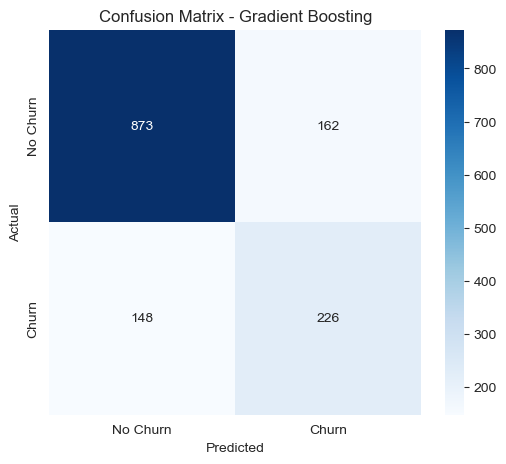

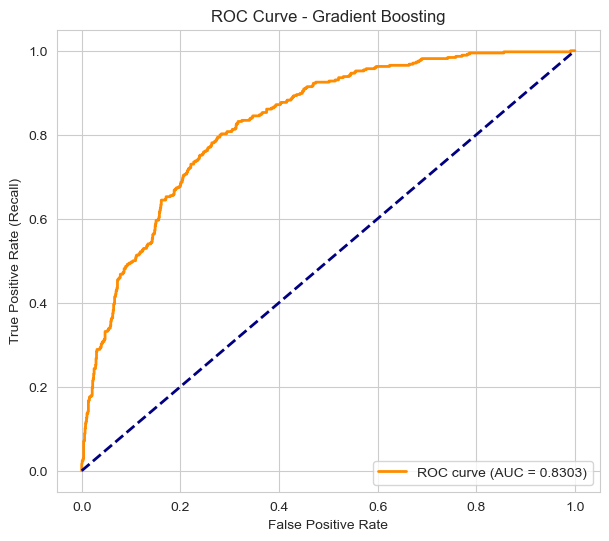

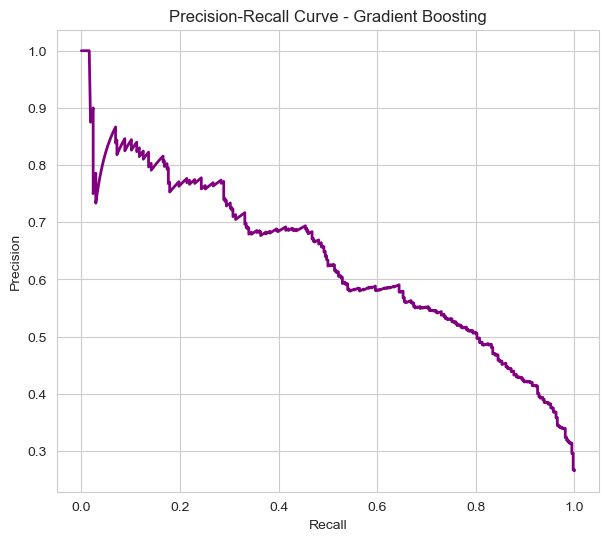

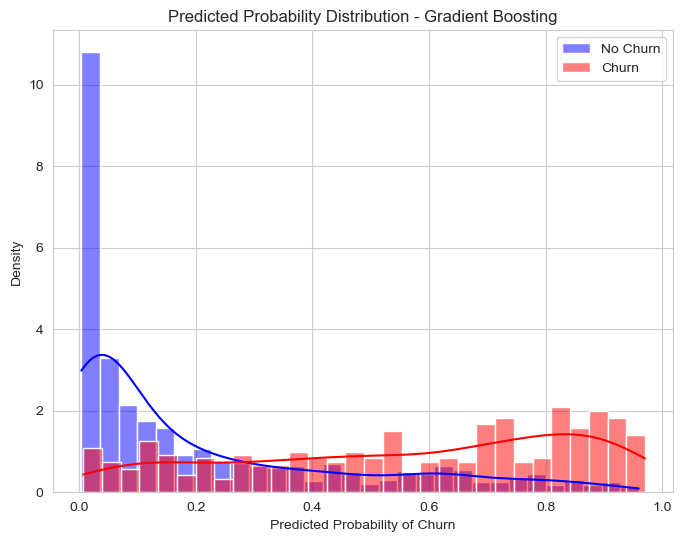

In [14]:
# 1️⃣ Confusion Matrix Heatmap
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2️⃣ ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, final_y_pred_proba)
roc_auc_val = roc_auc_score(y_test, final_y_pred_proba)  # You already imported roc_auc_score

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc='lower right')
plt.show()

# 3️⃣ Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, final_y_pred_proba)
plt.figure(figsize=(7,6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.show()

# 4️⃣ Prediction Probability Distribution
plt.figure(figsize=(8,6))
sns.histplot(final_y_pred_proba[y_test==0], color='blue', label='No Churn', kde=True, stat="density", bins=30)
sns.histplot(final_y_pred_proba[y_test==1], color='red', label='Churn', kde=True, stat="density", bins=30)
plt.title(f'Predicted Probability Distribution - {best_model_name}')
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('Density')
plt.legend()
plt.show()